# Yahoo! Finance

Yahoo! recently created an [API](https://pypi.org/project/yfinance/) at the end of 2022 that allows users to easily find information directly from their [finance website](https://finance.yahoo.com/).

Let's take a look at the API and some high-level capabilities.

In [1]:
# fetch the yahoo api for analysis
from datetime import datetime
import yfinance as yf
import pandas as pd
import numpy as np
import json

As I pull data from Yahoo!, I am compiling a dictionary of stock tickers that can be referenced for analysis.

In [2]:
f = open('_stocks.json')
instruments = json.load(f)
f.close()

## Simple Analysis
We can select a list of stocks to analyze and then determine the date range for which we want to analyze historical data. I will look at a few selections over the past decade, including a few key indexes for reference.

In [3]:
stocks = ['NXPI', 'TSLA', 'PLUG', '^IXIC', 'SPY', 'GLD']

In [4]:
start_date = datetime(2013,1,1)
end_date = datetime(2023,1,1)

This pulls the data from yFinance and then creates a dataframe of all the stock prices at close for every day in the selected date range. We'll drop the days where there were no trading. 

In [5]:
tick_data = yf.download(stocks, start=start_date, end=end_date)
eod = tick_data['Adj Close']
for symbol in eod.columns:
    print('{:8s} | {}'.format(symbol, instruments[symbol]))

[*********************100%***********************]  6 of 6 completed
GLD      | SPDR Gold Trust
NXPI     | NXP Semiconductors
PLUG     | Plug Power
SPY      | SPDR S&P 500 ETF Trust
TSLA     | Tesla Stock
^IXIC    | Nasdaq Composite


In [6]:
eod = eod.dropna()
eod.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2518 entries, 2013-01-02 to 2022-12-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GLD     2518 non-null   float64
 1   NXPI    2518 non-null   float64
 2   PLUG    2518 non-null   float64
 3   SPY     2518 non-null   float64
 4   TSLA    2518 non-null   float64
 5   ^IXIC   2518 non-null   float64
dtypes: float64(6)
memory usage: 137.7 KB


In [7]:
eod.head()

,GLD,NXPI,PLUG,SPY,TSLA,^IXIC
Date,,,,,,
2013-01-02,163.169998,26.161810,0.50,121.308090,2.357333,3112.260010
2013-01-03,161.199997,26.030207,0.51,121.034058,2.318000,3100.570068
2013-01-04,160.440002,25.701181,0.53,121.565598,2.293333,3101.659912
2013-01-07,159.429993,25.513170,0.53,121.233406,2.289333,3098.810059
2013-01-08,160.559998,24.958538,0.54,120.884567,2.245333,3091.810059


Here I'm showing the normalized prices of each instrument from my selection.

<AxesSubplot: xlabel='Date'>

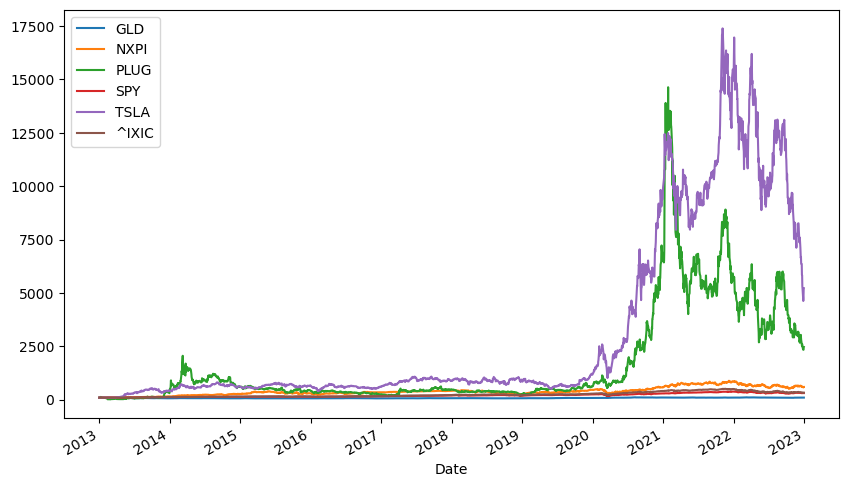

In [8]:
(eod / eod.iloc[0] * 100).plot(figsize=(10, 6))

Now we take the data and find log returns for each stock. Using log returns instead of simple returns for time series analysis helps us reduce variation and create more accurate predictive models on a stock.

In [9]:
log_returns = np.log(eod / eod.shift(1))
log_returns.head()

,GLD,NXPI,PLUG,SPY,TSLA,^IXIC
Date,,,,,,
2013-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-03,-0.012147,-0.005043,0.019803,-0.002262,-0.016826,-0.003763
2013-01-04,-0.004726,-0.012721,0.038466,0.004382,-0.010699,0.000351
2013-01-07,-0.006315,-0.007342,0.000000,-0.002736,-0.001746,-0.000919
2013-01-08,0.007063,-0.021979,0.018692,-0.002882,-0.019407,-0.002261


From our log returns, we can plot the data and look at some simple, informative statistics of the distribution.

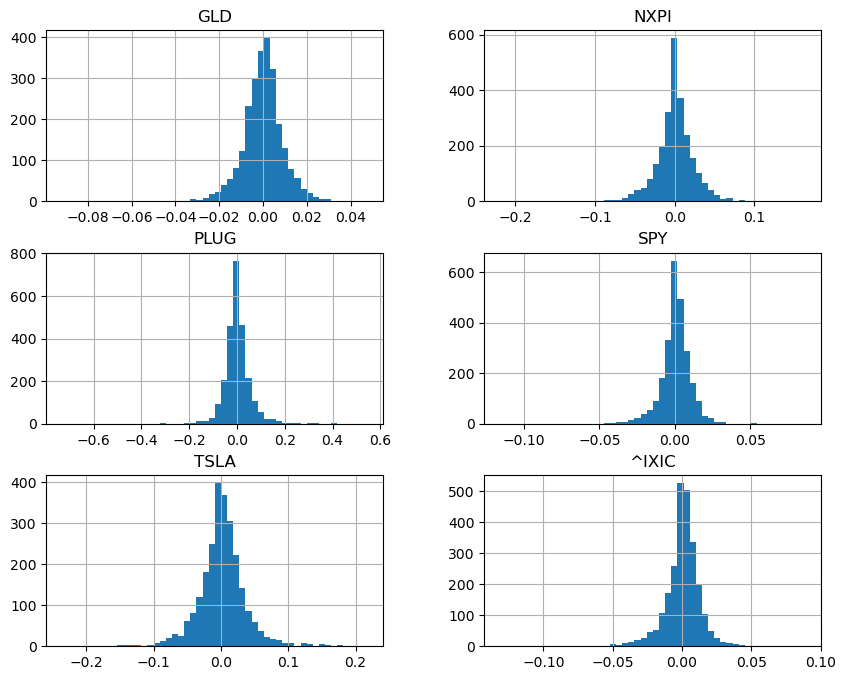

In [10]:
log_returns.hist(bins=50, figsize=(10, 8));

In [11]:
for stock in stocks:
    log_data = pd.DataFrame(log_returns[stock].dropna())
    print('\nResults for {}'.format(instruments[stock]))
    print(30 * '-')
    print(log_data.describe())
    print("skew\t", log_data.skew().values[0])
    print("kurtosis ", log_data.kurt().values[0])


Results for NXP Semiconductors
------------------------------
              NXPI
count  2517.000000
mean      0.000715
std       0.025014
min      -0.219521
25%      -0.010204
50%       0.000691
75%       0.012229
max       0.164716
skew	 -0.343734316368472
kurtosis  9.308178198628188

Results for Tesla Stock
------------------------------
              TSLA
count  2517.000000
mean      0.001572
std       0.035858
min      -0.236518
25%      -0.015065
50%       0.001300
75%       0.018793
max       0.218292
skew	 0.005997893852257731
kurtosis  5.031366160604798

Results for Plug Power
------------------------------
              PLUG
count  2517.000000
mean      0.001275
std       0.060556
min      -0.733969
25%      -0.025318
50%       0.000000
75%       0.023531
max       0.548566
skew	 0.17330077675499006
kurtosis  20.495533696932267

Results for Nasdaq Composite
------------------------------
             ^IXIC
count  2517.000000
mean      0.000482
std       0.013053
min      -0.1

## Additional yFinance Features

yFinance gives us some additional API features that we can build into our models/analysis. Looking at an individual stock, for example, we can pull in all sorts of meta data. 

In [12]:
tsla = yf.Ticker("TSLA")

This will pull the current market price for the stock

In [13]:
price = tsla.info['regularMarketPrice']
price

118.85

A break down of the % of shares held by different entities

In [14]:
tsla.major_holders

,0,1
0,16.33%,% of Shares Held by All Insider
1,45.82%,% of Shares Held by Institutions
2,54.76%,% of Float Held by Institutions
3,3434,Number of Institutions Holding Shares


Looking at the earnings trend for this stock. Consider here - you might want to keep your portfolio safe in a JSON file, like I opened at the beginning of this notebook, and scan the earnings trends of each stock you are holding shares in.

In [15]:
tsla.earnings_trend

,Max Age,End Date,Growth,Earnings Estimate Avg,Earnings Estimate Low,Earnings Estimate High,Earnings Estimate Year Ago Eps,Earnings Estimate Number Of Analysts,Earnings Estimate Growth,Revenue Estimate Avg,...,Revenue Estimate Growth,Eps Trend Current,Eps Trend 7Days Ago,Eps Trend 30Days Ago,Eps Trend 60Days Ago,Eps Trend 90Days Ago,Eps Revisions Up Last7Days,Eps Revisions Up Last30Days,Eps Revisions Down Last30Days,Eps Revisions Down Last90Days
Period,,,,,,,,,,,,,,,,,,,,,
0Q,1,2022-12-31,0.38800,1.18,0.92,1.51,0.85,22.0,0.388,2.496370e+10,...,0.409,1.18,1.22,1.27,1.26,1.28,0.0,2.0,1.0,NaN
+1Q,1,2023-03-31,0.04700,1.12,0.82,1.38,1.07,14.0,0.047,2.421410e+10,...,0.291,1.12,1.19,1.29,1.29,1.31,0.0,1.0,1.0,NaN
0Y,1,2022-12-31,0.79200,4.05,3.60,4.48,2.26,29.0,0.792,8.245570e+10,...,0.532,4.05,4.01,4.11,4.10,4.10,0.0,4.0,1.0,NaN
+1Y,1,2023-12-31,0.24400,5.04,3.77,6.39,4.05,30.0,0.244,1.107000e+11,...,0.343,5.04,5.29,5.59,5.64,5.87,0.0,2.0,1.0,NaN
+5Y,1,NaT,0.34820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-5Y,1,NaT,0.85009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We can also pull the balance sheets, income statements, and cash flow over the last three years.

In [16]:
tsla.balance_sheet

,2021-12-31,2020-12-31,2019-12-31
Total Assets,62131000000.0,52148000000.0,34309000000.0
Current Assets,27100000000.0,26717000000.0,12103000000.0
Cash Cash Equivalents And Short Term Investments,17707000000.0,19384000000.0,6268000000.0
Cash And Cash Equivalents,17576000000.0,19384000000.0,6268000000.0
Other Short Term Investments,131000000.0,NaN,NaN
...,...,...,...
Tangible Book Value,28472000000.0,21705000000.0,6081000000.0
Total Debt,8873000000.0,13279000000.0,14697000000.0
Net Debt,NaN,NaN,5533000000.0
Share Issued,3099000000.0,2880000000.0,2715931290.0


In [17]:
tsla.income_stmt

,2021-12-31,2020-12-31,2019-12-31
Total Revenue,53823000000.0,31536000000.0,24578000000.0
Operating Revenue,53823000000.0,31536000000.0,24578000000.0
Cost Of Revenue,40217000000.0,24906000000.0,20509000000.0
Gross Profit,13606000000.0,6630000000.0,4069000000.0
Operating Expense,7110000000.0,4636000000.0,3989000000.0
Selling General And Administration,4517000000.0,3145000000.0,2646000000.0
Research And Development,2593000000.0,1491000000.0,1343000000.0
Operating Income,6496000000.0,1994000000.0,80000000.0
Net Non Operating Interest Income Expense,-315000000.0,-718000000.0,-641000000.0
Interest Income Non Operating,56000000.0,30000000.0,44000000.0


In [18]:
tsla.cashflow

,2021-12-31,2020-12-31,2019-12-31
Operating Cash Flow,11497000000.0,5943000000.0,2405000000.0
Cash Flow From Continuing Operating Activities,11497000000.0,5943000000.0,2405000000.0
Net Income From Continuing Operations,5644000000.0,862000000.0,-775000000.0
Operating Gains Losses,-82000000.0,231000000.0,98000000.0
Gain Loss On Sale Of PPE,-27000000.0,117000000.0,146000000.0
Net Foreign Currency Exchange Gain Loss,-55000000.0,114000000.0,-48000000.0
Depreciation Amortization Depletion,2911000000.0,2322000000.0,2154000000.0
Depreciation And Amortization,2911000000.0,2322000000.0,2154000000.0
Depreciation,2911000000.0,NaN,NaN
Asset Impairment Charge,140000000.0,202000000.0,193000000.0
